# Creating a grid of `bapec` spectra with varying temperature and abundance

In order to create the photon list, I need to get the spectrum at each point of my simulated cluster. This many calls to xspec can be expensive. Instead, I interpolate spectra in temperature and abundance as it is much faster. In the following notebook I create a grid of spectra for different temperatures and abundances.
This can perhaps be extended to one or two additional parameters but at the cost of having a very large interpolation table. To have more parameters (i.e. for a bvvapec) this may not work anymore.

In [30]:
import numpy as np
import matplotlib.pyplot as plt
import xspec as xs
import cmasher as cmr

## Limiting the prints from xspec

In [2]:
class XSilence(object):
    """Context for temporarily making XS quiet."""

    def __enter__(self):
        self.oldchatter = xs.Xset.chatter, xs.Xset.logChatter
        xs.Xset.chatter, xs.Xset.logChatter = 0, 0

    def __exit__(self, *args):
        xs.Xset.chatter, xs.Xset.logChatter = self.oldchatter

## Parallelized functions to create many spectra

Perhaps these functions could be used instead of the interpolation. To be checked in the future.

In [3]:
import os
import tempfile
import numpy as np
import re
from tqdm.auto import tqdm
from contextlib import contextmanager, nullcontext
import multiprocessing

Function that reads the lines from an xcm file and gets its parameter values

In [4]:
def get_model_block(lines):
    """
    Find the lines related to the model parameters in an .xcm file
    """

    in_model_block = False
    out_lines = []
    out_lines_indexes = []
    model_indexes = []
    parameter_indexes = []

    model_pattern = re.compile(r'^model(?:\s+(?:(\d+):(\S+)))?\b')

    for i, line in enumerate(lines):
        stripped = line.lstrip()

        if not stripped or stripped.startswith("#"):
            continue

        tokens = stripped.split()
        head = tokens[0]

        if head == "model":
            in_model_block = True
            m = model_pattern.match(stripped)

            current_parameter_index = 1

            if m.group(1) is not None:
                current_model_index = int(m.group(1))
            else:
                current_model_index = None

            if m.group(2) is not None:
                current_model_name = str(m.group(2))
            else:
                current_model_name = ""

            # Than we skip to the next iteration
            continue

        if head == "bayes":
            in_model_block = False
            continue

        if in_model_block:
            out_lines.append(line)
            out_lines_indexes.append(i)
            parameter_indexes.append(current_parameter_index)
            model_indexes.append(current_model_name)

            current_parameter_index += 1
            continue


    return {
        (model_name, int(par_index)): (out_line, line_number)
        for par_index, model_name, out_line, line_number in zip(
            parameter_indexes, model_indexes, out_lines, out_lines_indexes
        )
    }

Function that reads an xcm file and gives the right values of parameters to the model

In [5]:
@contextmanager
def local_xcm_path(params, indexes, model_indexes, base_xcm_path, *, tmp_dir=None):
    """
    Build a local .xcm file path containing the values specified in params, using a base xcm path.
    """

    with open(base_xcm_path, "r") as f:
        lines = f.readlines()
        mapping = get_model_block(lines)


    for model_name, parameter_index, value in zip(model_indexes, indexes, params):
        line, line_index = mapping[(model_name, parameter_index)]
        line = f"{value:.8g}".rjust(15) + line[15:]
        lines[line_index] = line

    with tempfile.NamedTemporaryFile(
        mode="w",
        suffix=".xcm",
        dir=tmp_dir,
        delete=False,
    ) as tmp_file:
        tmp_file.writelines(lines)
        local_xcm_path = tmp_file.name

    try:
        yield local_xcm_path

    finally:
        try:
            os.remove(local_xcm_path)
        except FileNotFoundError:
            pass

Parallelized function

In [6]:
def parallel_folding(
    params, indexes, model_indexes, desc="", progress_bar=True, pool=None
):
    """Perform simulation in parallel with xs.

    Returns:
        dict[str, torch.Tensor]: Dictionary containing the stacked spectra under
            the ``spectra`` key and the corresponding Cash statistics under
            ``cstat``.
    """

    with tempfile.TemporaryDirectory(prefix="parallel_folding_") as tmp_dir:
        model_file = os.path.join(tmp_dir, "model_template.xcm")
        xs.Xset.save(model_file, info="m")

        progress_cm = (
            tqdm(total=len(params), desc=desc)
            if progress_bar
            else nullcontext()
        )

        with progress_cm as pbar:

            def update_progress(_):
                if pbar is not None:
                    pbar.update()

            in_pool = pool is not None

            if not in_pool:

                outputs = [
                    folded_model_from_parameters(param, indexes, model_indexes, model_file, apply_stat, tmp_dir, in_pool)
                    for param in params
                ]

            else:

                results = [
                    pool.apply_async(
                        folded_model_from_parameters,
                        (param, indexes, model_indexes, model_file, tmp_dir, in_pool),
                        callback=update_progress,
                    )
                    for param in params
                ]

                outputs = [result.get() for result in results]

        spectra = np.vstack([spectra for spectra in outputs])

        return spectra

Function that actually computes the spectra

In [7]:
def folded_model_from_parameters(params, indexes, model_indexes, model_file, tmp_dir, in_pool):

    with XSilence():
        with local_xcm_path(params, indexes, model_indexes, model_file, tmp_dir=tmp_dir) as local_xcm:
            xs.Xset.restore(local_xcm)
            
        

        xs.Fit.statMethod = "cstat"
        xs.Fit.bayes = "off" # <- we handle the prior logprob on our own
        sources_models = xs.AllModels.sources


        count_list = []
        stat_list = []

        
        expected_rate = 0
        for source, model_name in zip(sources_models.keys(), sources_models.values()):
            model = xs.AllModels(1,model_name)
            expected_rate += np.asarray(model.values(0))
                

            count_list.append((expected_rate))

        spectra = np.hstack(count_list)

        stat_list.append(float(xs.Fit.statistic))

        if in_pool:
            xs.AllModels.clear()  # VERY IMPORTANT : speedup of ~4 for unknown reasons

    return spectra

## Create the model

Initialize xspec and clear all

In [8]:
xs.AllData.clear()
xs.AllModels.clear()

# Some settings for XS
xs.Fit.statMethod = "cstat"
xs.Fit.bayes = "off"
xs.Xset.xsect = "vern"
xs.Xset.abund = "angr"

Default fit statistic is set to: C-Statistic
   This will apply to all current and newly loaded spectra.
 Cross Section Table set to vern:  Verner, Ferland, Korista, and Yakovlev 1996
 Solar Abundance Vector set to angr:  Anders E. & Grevesse N. Geochimica et Cosmochimica Acta 53, 197 (1989)


### Model

In [9]:
m = xs.Model('phabs*bapec')

Reading APEC data from 3.0.9


Model phabs<1>*bapec<2> Source No.: 1   Active/Off
Model Model Component  Parameter  Unit     Value
 par  comp
   1    1   phabs      nH         10^22    1.00000      +/-  0.0          
   2    2   bapec      kT         keV      1.00000      +/-  0.0          
   3    2   bapec      Abundanc            1.00000      frozen
   4    2   bapec      Redshift            0.0          frozen
   5    2   bapec      Velocity   km/s     0.0          frozen
   6    2   bapec      norm                1.00000      +/-  0.0          
________________________________________________________________________



In [10]:
# Typical value of hydrogen column density at a high galactic latitude
nH = 0.03

# Redshift of my cluster
redshift = 0.1

# Norm is fixed to 1
norme = 1

# Velocity broadening is fixed to 1
broad = 0

# Random values to initialize the model
T_debut = 1.
Z_debut = 0.5

In [11]:
m.setPars({1:nH,
           2:T_debut,
           3:Z_debut,
           4:redshift,
           5:broad,
           6:norme})
m(3).frozen = False

In [12]:
m.show()


Model phabs<1>*bapec<2> Source No.: 1   Active/Off
Model Model Component  Parameter  Unit     Value
 par  comp
   1    1   phabs      nH         10^22    3.00000E-02  +/-  0.0          
   2    2   bapec      kT         keV      1.00000      +/-  0.0          
   3    2   bapec      Abundanc            0.500000     +/-  0.0          
   4    2   bapec      Redshift            0.100000     frozen
   5    2   bapec      Velocity   km/s     0.0          frozen
   6    2   bapec      norm                1.00000      +/-  0.0          
________________________________________________________________________



### Grid of energies

X-IFU range of energy is 0.2 to 12 keV. The energy step needs to be much smaller than the energy resolution.

In [13]:
E_min = 0.2
E_max = 12.
E_step = 4e-4
nb_bins_E = int((E_max-E_min)/E_step)

In [14]:
# Dummy response to evaluate the model at a fixed energy grid
xs.AllData.dummyrsp(E_min,
                    E_max,
                    nb_bins_E,
                    "lin",
                    0.2,
                    E_step)

In [15]:
model = xs.AllModels(1,'')

In [16]:
model.show()


Model phabs<1>*bapec<2> Source No.: 1   Active/Off
Model Model Component  Parameter  Unit     Value
 par  comp
   1    1   phabs      nH         10^22    3.00000E-02  +/-  0.0          
   2    2   bapec      kT         keV      1.00000      +/-  0.0          
   3    2   bapec      Abundanc            0.500000     +/-  0.0          
   4    2   bapec      Redshift            0.100000     frozen
   5    2   bapec      Velocity   km/s     0.0          frozen
   6    2   bapec      norm                1.00000      +/-  0.0          
________________________________________________________________________



## Grid of parameters

The parameters should have the range spanned by the values within the simulated object. The 121,81 are arbitrary values used to match previous versions of the code and compare. These can be 100,100. Keep in mind that the apec model is itself interpolated on a grid of temperature, and it is useless to bin too finely in temperature.

In [17]:
T_scale = np.linspace(1.,7.,121)
Z_scale = np.linspace(0.1,0.9,81)

In [18]:
T_values, Z_values = np.meshgrid(T_scale, Z_scale)

In [19]:
params = np.array([T_values.flatten(), Z_values.flatten()]).T

## Creating the grid of interpolated spectra

In [20]:
# Indexes of parameters T and Z in the model
indexes = [2, 3]

# This is just a quick patch because I adapted the code from elsewhere. Keep it like that and don't ask questions
model_indexes = ['', '']

In [21]:
# Number of available cores (32 for NUWA)
n_jobs = 32

In [22]:
# Initialize the parallel processes
pool = multiprocessing.Pool(processes=n_jobs)

In [23]:
# Computation of spectra
spectra = parallel_folding(
    params, indexes, model_indexes, desc="Creating spectra", progress_bar=True, pool=pool
)

Creating spectra:   0%|          | 0/9801 [00:00<?, ?it/s]

In [24]:
## Reshaping the spectra to correspond to the actual shape of T and Z 
spectra_reshaped = spectra.reshape(81,121,29500)

## Plotting the spectra

In [25]:
E_bins = np.linspace(E_min, E_max, nb_bins_E)

Spectrum as a function of abundance

Text(0, 0.5, 'Model flux [ph/cm2/s/keV]')

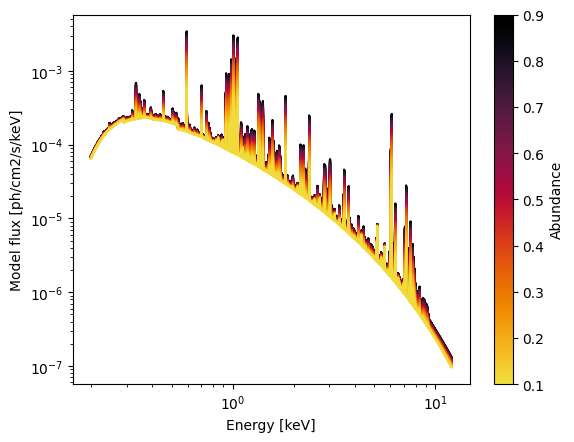

In [51]:
colors = cmr.take_cmap_colors(cmr.ember_r, N = 81)
for k in range(80,0,-1):
    plt.loglog(E_bins, spectra_reshaped[k,50], c = colors[k])
    
sm = plt.cm.ScalarMappable(cmap=cmr.ember_r, norm=plt.Normalize(vmin=Z_scale.min(), 
                                                              vmax=Z_scale.max()))
ax = plt.gca()
plt.colorbar(sm, label = r'Abundance', ax = ax)

plt.xlabel('Energy [keV]')
plt.ylabel('Model flux [ph/cm2/s/keV]')


Spectrum as a function of temperature

Text(0, 0.5, 'Model flux [ph/cm2/s/keV]')

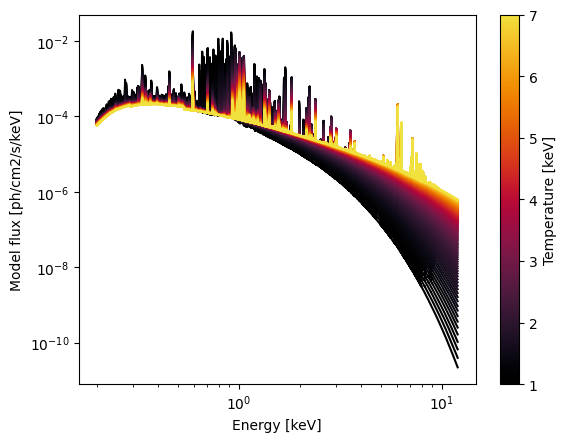

In [42]:
colors = cmr.take_cmap_colors(cmr.ember, N = 121)

for k in range(121):
    plt.loglog(E_bins, spectra_reshaped[50,k], c = colors[k])
    
sm = plt.cm.ScalarMappable(cmap=cmr.ember, norm=plt.Normalize(vmin=T_scale.min(), 
                                                              vmax=T_scale.max()))
ax = plt.gca()
plt.colorbar(sm, label = r'Temperature [keV]', ax = ax)

plt.xlabel('Energy [keV]')
plt.ylabel('Model flux [ph/cm2/s/keV]')

## Save data

I'm keeping the same format from previous versions of the code, this can be changed in principle

```python
np.savez('../data/spectres_interpoles_T_Z.npz',
        T_scale = T_scale,
        Z_scale = Z_scale,
        spectra = spectra_reshaped)
        
```

## Old version : 

```python
import xspec as xs
import numpy as np
from multiprocessing import Pool

xs.Xset.chatter = 0

xs.Xset.allowPrompting = False

def getcountsTZ(TZ_vec,
	nH = 0.03, #10^22 cm-2
	z  = 0.1,  #Cluster redshift
	norm = 1,  #For normalisation
	v = 0.,   #Velocity broadening
	):
	
	T, Z = TZ_vec

	xs.AllData.clear()
	#Load instrument responses
	fs1 = xs.FakeitSettings(response = "/xifu/home/mola/XIFU_Sims_Turbulence_NewConfig/RMF.rmf", 
	                        arf = '/xifu/home/mola/XIFU_Sims_Turbulence_NewConfig/ARF.arf',
	                        exposure=1.0)

	#Define models
	m = xs.Model('phabs*bapec')

	#Define parameters
	m.setPars(nH, T, Z, z, v, norm)

	#Fakeit
	xs.AllData.fakeit(1, fs1, noWrite = True)

	#Folded flux
	flux = np.sum(np.array(m.folded(1))) #ph/s
	#This is the sum of the number of expected number photons received on the detector for the given one second exposure

	return flux 


if __name__ == '__main__' :

	Npts = 100
	T_list = np.linspace(0.1, 10, Npts)
	Z_list = np.linspace(0.01, 1, Npts)
	mesh = np.meshgrid(T_list, Z_list)
	TZ = np.vstack((mesh[0].flatten(), mesh[1].flatten())).T
	
	p = Pool(32)
	flux_table = p.map(getcountsTZ, TZ)
	print(flux_table)

	np.save('flux_table_APEC_newXIFU.npy', flux_table)
```